# USGS mineral library — `HyFourier` maps by instrument

Loads all Chapter M mineral spectra from the USGS splib07b ASCII library, splits them by
**acquisition instrument** (wavelength sampling / band count), assigns **mineral-family groups**
from `mineral_families.csv`, builds one **`HyFourier` map per instrument** in a
**`FourierArchive`**, saves outputs under `sandbox/usgs_fourier/`, and runs a test spectral search.

In [1]:
import os
import glob
import re
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

import hylite
from hylite import io
from hylite import HyLibrary
from hylite.analyse.fourier import HyFourier, FourierArchive, FOURIER_ARCHIVE_EXTENSION

USGS_ROOT = '/Users/thiele67/Documents/data/Libraries/Spectra USGS/ASCIIdata_splib07b'
MINERALS_DIR = os.path.join(USGS_ROOT, 'ChapterM_Minerals')
FAMILIES_CSV = '/Users/thiele67/Documents/data/Libraries/Spectra USGS/mineral_families.csv'
REPO_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(hylite.__file__)))
OUT_DIR = os.path.join(REPO_ROOT, 'sandbox', 'usgs_fourier')
os.makedirs(OUT_DIR, exist_ok=True)

NAN_VALUE = -1.23e34

## 1. Wavelength grids and instrument order

Each USGS `.txt` spectrum uses one of the companion `*Wavelengths*.txt` files. We treat each
unique band count as an instrument and sort by covered wavelength range (shortest λ first).

In [2]:
# load wavelength axes (nm) keyed by band count
wav_by_n = {}
wav_label = {}
for path in glob.glob(os.path.join(USGS_ROOT, '*Wavelengths*.txt')):
    w = np.loadtxt(path, skiprows=1, dtype=np.float64) * 1000.0
    wav_by_n[len(w)] = w
    wav_label[len(w)] = os.path.basename(path)

def instrument_key(n_bands):
    label = wav_label[n_bands].lower()
    if 'beck' in label:
        return 'beck'
    if 'asdf' in label:
        return 'asdf'
    if 'aviris' in label:
        return 'aviris'
    if 'nic4' in label:
        return 'nic4'
    return f'n{n_bands}'


def make_instrument(n_bands):
    w = wav_by_n[n_bands]
    return {
        'key': instrument_key(n_bands),
        'n_bands': n_bands,
        'wav': w,
        'label': wav_label[n_bands],
        'range_nm': (float(w[0]), float(w[-1])),
    }

## 2. Mineral families

In [3]:
families = {}
with open(FAMILIES_CSV, 'r') as f:
    for line in f:
        line = line.strip()
        if not line or ',' not in line:
            continue
        mineral, family = line.split(',', 1)
        families[mineral.strip().lower()] = family.strip().lower()

print(f'Loaded {len(families)} mineral → family mappings')

Loaded 212 mineral → family mappings


## 3. Load spectra and assign to instruments

In [4]:
def mineral_from_filename(path):
    """USGS splib07b names are splib07b_<Mineral>_..."""
    return os.path.basename(path).split('_')[1].lower()


def load_usgs_spectrum(path):
    r = np.loadtxt(path, skiprows=1, dtype=np.float32)
    r[r == NAN_VALUE] = np.nan
    return r


# bucket file paths by band count (instrument wavelength grid)
paths_by_n = defaultdict(list)
for path in sorted(glob.glob(os.path.join(MINERALS_DIR, '*.txt'))):
    n = len(load_usgs_spectrum(path))
    if n not in wav_by_n:
        raise ValueError(f'No wavelength file for {n} bands: {path}')
    paths_by_n[n].append(path)

# instruments present in Chapter M, sorted by wavelength coverage
INSTRUMENTS = [
    make_instrument(n_bands)
    for n_bands in sorted(paths_by_n.keys(), key=lambda n: wav_by_n[n][0])
]
for inst in INSTRUMENTS:
    inst['paths'] = paths_by_n[inst['n_bands']]

print('Instruments (sorted by minimum wavelength):')
for inst in INSTRUMENTS:
    print(f"  {inst['key']:6s}  n={inst['n_bands']:4d}  "
          f"{inst['range_nm'][0]:8.1f}-{inst['range_nm'][-1]:8.1f} nm  "
          f"{len(inst['paths'])} spectra")

Instruments (sorted by minimum wavelength):
  beck    n=3961     205.0-  2976.0 nm  439 spectra
  asdf    n=2151     350.0-  2500.0 nm  448 spectra
  nic4    n=4595    1122.6-216006.0 nm  389 spectra


## 4. Build `HyLibrary` groups and `HyFourier` maps per instrument

In [5]:
def feature_wavelength_range(inst):
    """Clip to VNIR/SWIR window supported by this instrument grid."""
    w = inst['wav']
    #lo = np.min(w)
    #hi = np.max(w)
    
    lo = max(400.0, float(w[0]))
    #swir = w[w <= 2500.0]
    hi = min(15000.0, float(w[-1]))
    print(lo,hi)
    return lo, hi


def build_instrument_library(inst):
    """Return HyLibrary with mineral-family groups for one instrument."""
    names, spectra = [], []
    for path in inst['paths']:
        names.append(os.path.splitext(os.path.basename(path))[0])
        spectra.append(load_usgs_spectrum(path))
    data = np.stack(spectra, axis=0)[:, None, :]
    lib = HyLibrary(data, lab=names, wav=inst['wav'])

    # HyLibrary groups keyed by mineral family
    group_ids = defaultdict(list)
    for i, path in enumerate(inst['paths']):
        mineral = mineral_from_filename(path)
        family = families.get(mineral, 'unclassified')
        group_ids[family].append(i)
    for family, ids in sorted(group_ids.items()):
        lib.add_group(family, ids)
    return lib


libraries = {}
archive = FourierArchive()
for inst in INSTRUMENTS:
    key = inst['key']
    print(f'Building {key} ...')
    lib = build_instrument_library(inst)
    libraries[key] = lib

    # SWIR-focused subset for feature mapping (respects each instrument's λ coverage)
    lo, hi = feature_wavelength_range(inst)
    subset = lib.export_bands((lo, hi))
    hf = HyFourier(subset, padding='cosine', max_freq=0.25, vb=True)
    hf.precomputeExtrema(kde_sigma=10.0, vb=True)
    archive[key] = hf
    print(f'  library: {lib.sample_count()} samples, groups: {len(lib.get_groups())}')
    print(f'  HyFourier ({lo:.0f}-{hi:.0f} nm): {hf.data.shape}')

Building beck ...
400.0 2976.0000999999997


  library: 439 samples, groups: 40
  HyFourier (400-2976 nm): (439, 845, 2)
Building asdf ...
400.0 2500.0


  library: 448 samples, groups: 34
  HyFourier (400-2500 nm): (448, 525, 2)
Building nic4 ...
1122.5605999999998 15000.0


  library: 389 samples, groups: 38
  HyFourier (1123-15000 nm): (389, 1069, 2)


## 5. Save libraries and Fourier maps

In [7]:
FDA_PATH = os.path.join(OUT_DIR, 'usgs_minerals')
archive.save(FDA_PATH)
print('Saved', FDA_PATH + FOURIER_ARCHIVE_EXTENSION)

Saved /Users/thiele67/Documents/python/hylite/sandbox/usgs_fourier/usgs_minerals.fda


## 6. Test query — absorptions near 2200 nm and 2160 nm

Uses `HyFourier.search()` naive-Bayes ranking (`2200 2160` = require both Al-OH style minima).

In [8]:
archive = FourierArchive.load(os.path.join(OUT_DIR, 'usgs_minerals'))
print('Loaded instruments:', list(archive.keys()))


Loaded instruments: ['beck', 'asdf', 'nic4']


  0.3744 (asdf) [topaz] splib07b_Topaz_HS184.3B_ASDNGb_AREF
  0.3655 (beck) [topaz] splib07b_Topaz_HS184.3B_BECKb_AREF
  0.3381 (beck) [topaz] splib07b_Topaz_Mt_Antero_#5_BECKb_AREF
  0.3258 (asdf) [topaz] splib07b_Topaz_HS184.4B_ASDNGb_AREF
  0.3016 (asdf) [topaz] splib07b_Topaz_HS184.3B_ASDFRb_AREF
  0.2782 (asdf) [topaz] splib07b_Topaz_HS184.4B_ASDFRb_AREF
  0.2691 (nic4) [topaz] splib07b_Topaz_HS184.3B_NIC4bc_RREF
  0.2578 (nic4) [topaz] splib07b_Topaz_Jos_#22_NIC4bb_RREF
  0.2541 (beck) [topaz] splib07b_Topaz_Crystal_Park_#2_BECKb_AREF
  0.2523 (beck) [topaz] splib07b_Topaz_Jos_#22_BECKb_AREF
  0.2473 (nic4) [topaz] splib07b_Topaz_Little_3_Mine_#41_NIC4bb_RREF
  0.2388 (beck) [topaz] splib07b_Topaz_Harris_Park_#3_BECKb_AREF
  0.2325 (beck) [topaz] splib07b_Topaz_Wigwam_Area_3_#13_BECKb_AREF
  0.2305 (beck) [topaz] splib07b_Topaz_Wigwam_Area_5_#15_BECKb_AREF
  0.2277 (asdf) [topaz] splib07b_Topaz_HS184.2B_ASDFRb_AREF


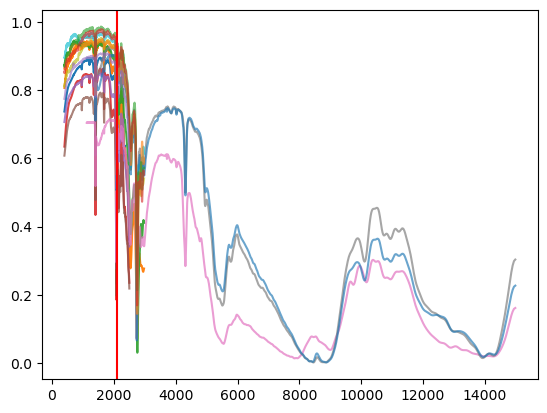

In [9]:
w = 2090.
QUERY = str(w)
CONFIDENCE = 20.0
N_RESULT = 15

names, scores = archive.search(QUERY, confidence=CONFIDENCE, n_result=N_RESULT)
for name, score in zip(names, scores):
    print(f'  {score:6.4f} {name}')
    
# plot the top match
for name, score in zip(names, scores):
    spectra = archive.getSpectra(name)
    plt.plot(spectra.get_wavelengths(), spectra.data[0,0,:], alpha=score / scores[0])
plt.axvline(w, color='r')
plt.show()

In [16]:
QUERY = 'mica' # n.b. amphibole should be included as a group key
CONFIDENCE = 20.0
N_RESULT = 15

for key in archive:
    names, scores = archive[key].search(QUERY, confidence=CONFIDENCE, n_result=N_RESULT)
    print(f'\n=== {key.upper()} — top matches for {QUERY!r} (±{CONFIDENCE} nm) ===')
    for name, score in zip(names, scores):
        print(f'  {score:6.4f} {name}')


=== BECK — top matches for 'mica' (±20.0 nm) ===
  1.0000 [white-mica] splib07b_Muscovite_GDS108_BECKb_AREF
  1.0000 [white-mica] splib07b_Muscovite_IL107_BECKb_AREF
  1.0000 [white-mica] splib07b_Margarite_GDS106_BECKc_AREF
  1.0000 [white-mica] splib07b_Muscovite_GDS107_BECKa_AREF
  1.0000 [white-mica] splib07b_Lepidolite_NMNH88526-1_BECKa_AREF
  1.0000 [white-mica] splib07b_Lepidolite_NMNH105543_BECKc_AREF
  1.0000 [white-mica] splib07b_Lepidolite_NMNH105541_BECKb_AREF
  1.0000 [white-mica] splib07b_Lepidolite_NMNH105538_BECKb_AREF
  1.0000 [white-mica] splib07b_Lepidolite_HS167.3B_BECKb_AREF
  1.0000 [white-mica] splib07b_Pyrophyllite_SU1421_BECKb_AREF
  1.0000 [white-mica] splib07b_Pyrophyllite_PYS1A_lt850um_BECKa_AREF
  1.0000 [white-mica] splib07b_Pyrophyllite_PYS1A_fine_gr_BECKa_AREF
  1.0000 [white-mica] splib07b_Rectorite_RAr-1_BECKd_AREF
  1.0000 [white-mica] splib07b_Glauconite_HS313.3B_BECKc_AREF
  1.0000 [white-mica] splib07b_Roscoelite_EN124_BECKb_AREF

=== ASDF — top m

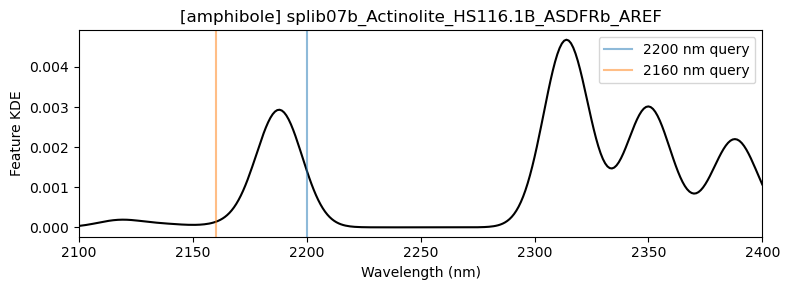

In [10]:
# optional: plot KDE match for the best ASDF hit
if 'asdf' in archive:
    hf = archive['asdf']
    names, scores = hf.search(QUERY, confidence=CONFIDENCE, n_result=1)
    from hylite.analyse.fourier import _sampleNames
    labels = _sampleNames(hf.header, hf.n_spectra, hf.original_shape, hf.spatial_shape)
    idx = labels.index(names[0])
    curve = hf.kde(2100, 2400, grid=True, index=idx)
    w = hf.get_wavelengths()
    plt.figure(figsize=(8, 3))
    plt.plot(w, curve, 'k-')
    plt.axvline(2200, color='C0', alpha=0.5, label='2200 nm query')
    plt.axvline(2160, color='C1', alpha=0.5, label='2160 nm query')
    plt.xlim(2100, 2400)
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Feature KDE')
    plt.title(names[0])
    plt.legend()
    plt.tight_layout()
    plt.show()